<a href="https://colab.research.google.com/github/Sshahsavar/credit-risk-modeling/blob/main/Part_4_Macroeconomic_Credit_Stress_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 4: Macroeconomic Stress Testing
*Credit risk project on Lending Club loans: Part 4 of 5*

## Project map

| Part | Topic | Main question | Main output |
|---|---|---|---|
| 0 | Data Foundation | What data do we need, and how do we prepare it? | Clean loan table and macro data |
| 1 | Loss Given Default (LGD) | How much do we lose when a borrower defaults? | LGD by grade and downturn LGD |
| 2 | PD Algorithm Benchmark | Which model predicts default best? | Choice of PD model |
| 3 | PD Scorecard and Credit Decisions | How do we build, check and use a PD model? | Calibrated PD, score, cut-off, stability check |
| **4** | **Macroeconomic Stress Testing (this part)** | **How much would the portfolio lose in a recession?** | **9-quarter loss by scenario** |
| 5 | Forward Flow and Securitization | Did the purchased loans perform as expected, and who carries the loss? | Monitoring, waterfall, tranche break-even |

The whole project is built around the expected loss formula, $EL = PD \times LGD \times EAD$. Part 1 measures LGD, Parts 2 and 3 measure PD, and Parts 4 and 5 add EAD, the economy and the investor view.

## What this part does

We take the Lending Club loans that were still running in March 2019 and ask: **how much of this portfolio would be lost over the next 9 quarters under a normal economy, a mild recession and a deep recession?** We build a PD model that moves with unemployment, combine it with the LGD model from Part 1 and a monthly EAD schedule, and project the losses quarter by quarter.

## How it connects to the other parts

* **Uses:**
  * the loan table and the macro data from Part 0;
  * the LGD model linked to unemployment from Part 1 (`lgd_satellite.json`).
* **Builds on Parts 2 and 3:** Parts 2 and 3 predict *whether* a loan defaults. A stress test must also know *when* it defaults and how the economy changes the risk each quarter, so here we use a time-based PD model (a hazard model).
* **Feeds:** Part 5 uses the scenario results of this part as stress scenarios for the securitization tranches.

## Why it matters for credit risk

A stress test asks *"what if?"* instead of *"what is most likely?"*. Regulators use stress tests to check that banks hold enough capital to survive a severe but plausible recession: the Federal Reserve's DFAST/CCAR in the US, and OSFI's stress testing guideline (E-18) in Canada. The same tools also drive the forward-looking scenarios in IFRS 9 provisions.

## Methodology

1. **Loan-quarter panel:** one row per loan for each quarter it was at risk, with default and prepayment flags and last quarter's state unemployment and GDP.
2. **PD model:** a discrete-time hazard model (logistic regression on the panel) with loan age, borrower risk and economic variables, plus a second model for prepayment.
3. **Backtest:** fit the model on older data and check how well it predicts the next 8 quarters, compared with a model without economic variables.
4. **Scenarios:** baseline, adverse and severely adverse paths for US unemployment and GDP, translated to each state.
5. **Loss projection:** expected loss each quarter = PD × LGD × EAD, over 9 quarters.
6. **Analysis:** loss by scenario, PD vs. LGD effect, loss by grade, sensitivity and a reverse stress test.

## Main results

* **Portfolio:** 873,780 current loans with \$9.13 billion outstanding.
* **Baseline 9-quarter loss:** \$868M (**9.5%** of the balance).
* **Recession scenarios barely raise the loss:** 9.6% in the adverse scenario and **9.7% in the severely adverse scenario (only 1.02× baseline)**.
* **The validation explains why.** The effect of the unemployment *level* has the wrong sign, the model with economic variables does not predict better than the model without them, and both under-predict defaults by 16%.
* **The cause:** Lending Club's lending became riskier while unemployment was falling (2010–2018), and the model confuses the two trends.
* **What this means:** the stress results are a **lower bound**, and the model needs a fix before real use. The most valuable result of this part is this validation finding and its diagnosis.

Tech stack: Python, pandas, NumPy, SciPy, Matplotlib, Google Colab.

# Step 1: Setup and Data Loading

**Why this step?** We need the loan table and macro data (Part 0) and the LGD model (Part 1). We also set the main settings of the stress test.

**How we do it.** We mount Google Drive, read the folder path from the Colab secret `credit_ris_DIR`, and load the files. The settings are:
* `SAMPLE_LOANS = 150,000`: loans used to fit the PD model. Each loan becomes about 8 rows, so the panel has about 1.2 million rows, which fits in a normal Colab session.
* `CO_LAG_Q = 2`: the panel stops 2 quarters before the snapshot date, because defaults in the last months are not visible yet (Part 0, Step 4).
* `H = 9`: the projection horizon in quarters, as in the Federal Reserve stress tests.

Dates are turned into quarter numbers (year × 4 + quarter − 1), which makes lags and horizons simple to compute.

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import expit, logit
from IPython.display import display
warnings.filterwarnings('ignore')

# 1.1. Mount Google Drive and define the project folder
from google.colab import drive
drive.mount('/content/drive')
import google.colab.userdata
PROJECT_DIR = google.colab.userdata.get('credit_ris_DIR')   # Colab secret that holds the Drive folder path


# 1.2. Stress-test settings
SAMPLE_LOANS = 150_000   # loans used to estimate the hazard models
CO_LAG_Q = 2             # censor the estimation panel 2 quarters before the snapshot
BACKTEST_Q = 8           # length of the out-of-time backtest window (quarters)
H = 9                    # projection horizon (quarters), as in DFAST/CCAR
RANDOM_STATE = 42

# 1.3. Load the Part 0 and Part 1 outputs
lc = pd.read_pickle(os.path.join(PROJECT_DIR, 'lc_clean.pkl'))
macro_state = pd.read_csv(os.path.join(PROJECT_DIR, 'macro_state_q.csv'))
macro_us = pd.read_csv(os.path.join(PROJECT_DIR, 'macro_us_q.csv'))
with open(os.path.join(PROJECT_DIR, 'as_of.txt')) as f:
    AS_OF = pd.Period(f.read().strip(), 'M')
with open(os.path.join(PROJECT_DIR, 'lgd_satellite.json')) as f:
    lgd_sat = json.load(f)

# 1.4. Quarter-number helpers
def qn_from_month(s):
    """Period[M] Series -> integer quarter number (year*4 + q-1); NaN-safe."""
    return (s.dt.year * 4 + (s.dt.month - 1) // 3).where(s.notna())

def qn_from_str(s):
    p = pd.PeriodIndex(s, freq='Q')
    return np.asarray(p.year * 4 + p.quarter - 1)

def qlabel(qn):
    qn = int(qn)
    return f"{qn // 4}Q{qn % 4 + 1}"

macro_state['qn'] = qn_from_str(macro_state['quarter'])
macro_us['qn'] = qn_from_str(macro_us['quarter'])
AS_OF_QN = AS_OF.year * 4 + (AS_OF.month - 1) // 3
END_QN = AS_OF_QN - CO_LAG_Q
STATES = sorted(macro_state['state'].unique())

print(f"Loans loaded: {len(lc):,}")
print(f"Snapshot: {qlabel(AS_OF_QN)} | Estimation panel ends: {qlabel(END_QN)} | "
      f"Projection: {qlabel(AS_OF_QN + 1)} to {qlabel(AS_OF_QN + H)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loans loaded: 2,260,668
Snapshot: 2019Q1 | Estimation panel ends: 2018Q3 | Projection: 2019Q2 to 2021Q2


# Step 2: The Loan-Quarter Panel

**Why this step?** A stress test needs more than a yes/no default prediction:
* **timing:** in which quarter does the default happen? Losses are projected quarter by quarter;
* **changing drivers:** the economy changes during the life of a loan;
* **loan age:** default risk rises in the first year of a loan and then falls ("seasoning");
* **open loans:** most loans have not finished, but they still carry information.

**How we do it.** We build a **loan-quarter panel**: one row per loan for each quarter it was at risk, from age 1 until it exits or the data ends.

| Exit type | Last row | Event flag in the last row |
|---|---|---|
| Default (before the panel ends) | default quarter | `d_default = 1` |
| Prepaid (before the panel ends) | payoff quarter | `d_prepay = 1` |
| Matured | maturity quarter | none |
| Still open, or exit after the panel ends | last panel quarter | none |

Each row gets the economy of the borrower's state in the **previous** quarter:
* `ur_lag`: the unemployment rate;
* `dur4_lag`: its change over 4 quarters;
* `gdp_lag`: US real GDP growth.

The one-quarter lag means the model only uses information that was available at the start of the quarter.

--- Building the Loan-Quarter Panel ---
133,037 loans -> 849,045 loan-quarters
Defaults: 15,218 | Prepayments: 47,303 | Average quarterly default rate: 1.792%


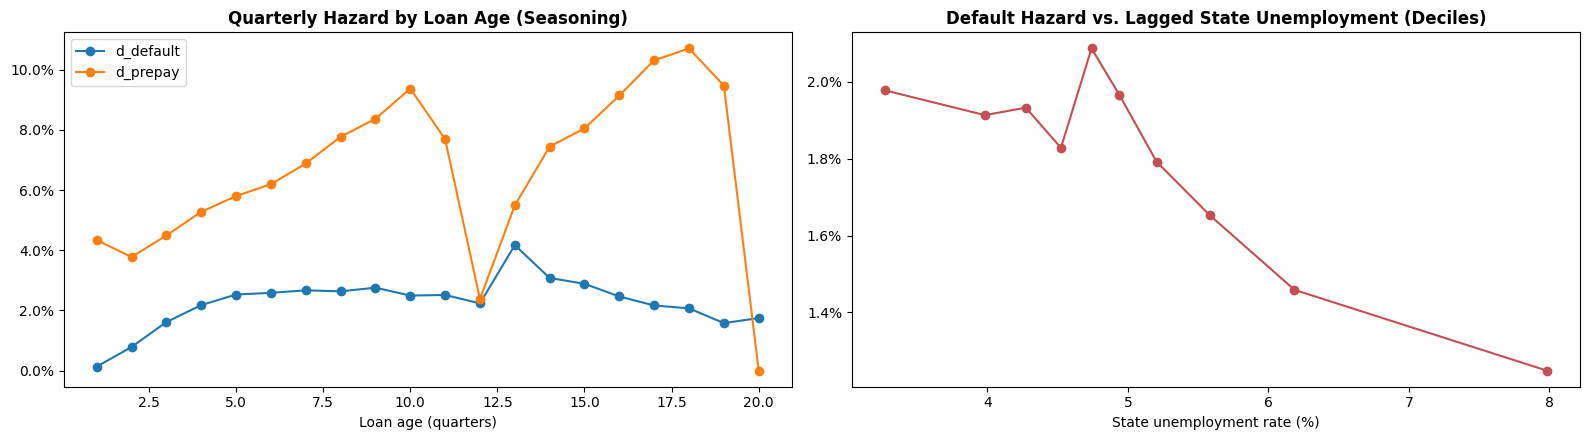

In [3]:
print("--- Building the Loan-Quarter Panel ---")

# 1. Fast (state, quarter) -> macro lookup
class MacroCube:
    """Stores ur, ur_chg4 and gdp_growth as dense state x quarter arrays for fast lookups."""
    def __init__(self, long):
        self.q0 = int(long['qn'].min())
        n_q = int(long['qn'].max()) - self.q0 + 1
        self.arr = {v: np.full((len(STATES), n_q), np.nan) for v in ['ur', 'ur_chg4', 'gdp_growth']}
        si = long['state'].map({s: i for i, s in enumerate(STATES)}).values
        qi = (long['qn'] - self.q0).astype(int).values
        for v in self.arr:
            self.arr[v][si, qi] = long[v].values
    def get(self, var, states, qn):
        si = pd.Series(states).map({s: i for i, s in enumerate(STATES)}).values.astype(float)
        qi = np.asarray(qn, int) - self.q0
        out = np.full(len(si), np.nan)
        ok = ~np.isnan(si) & (qi >= 0) & (qi < self.arr[var].shape[1])
        out[ok] = self.arr[var][si[ok].astype(int), qi[ok]]
        return out

macro_all = macro_state.merge(macro_us[['qn', 'ur_us', 'gdp_growth']], on='qn', how='left')
cube_actual = MacroCube(macro_all)

def add_macro(frame, cube):
    """Attach the lagged macro drivers to rows that have addr_state and cal_qn."""
    lag_q = frame['cal_qn'].values - 1
    frame['ur_lag'] = cube.get('ur', frame['addr_state'].values, lag_q)
    frame['dur4_lag'] = cube.get('ur_chg4', frame['addr_state'].values, lag_q)
    frame['gdp_lag'] = cube.get('gdp_growth', frame['addr_state'].values, lag_q)
    return frame

def loan_features(frame):
    f = frame.copy()
    f['log_annual_inc'] = np.log1p(f['annual_inc'].clip(lower=0))
    f['term_60'] = (f['term_m'] == 60).astype(int)
    f['issue_qn'] = qn_from_month(f['issue_m']).astype(int)
    return f

AGE_BINS = [0, 1, 2, 3, 4, 6, 8, 12, 99]
AGE_LABELS = ['1', '2', '3', '4', '5-6', '7-8', '9-12', '13+']
def age_bucket(age):
    return pd.cut(age, AGE_BINS, labels=AGE_LABELS).astype(str)

# 2. Sample loans and define the exit quarter and event of each loan
L = loan_features(lc.sample(n=min(SAMPLE_LOANS, len(lc)), random_state=RANDOM_STATE))
L = L[L['addr_state'].isin(STATES) & (L['issue_qn'] + 1 <= END_QN)].reset_index(drop=True)

exit_qn = qn_from_month(L['exit_m']).values
in_window = ~np.isnan(exit_qn) & (exit_qn <= END_QN)
event = np.where(in_window & L['exit_type'].eq('default'), 'default',
                 np.where(in_window & L['exit_type'].eq('prepaid'), 'prepaid', 'none'))
last_qn = np.maximum(np.where(in_window, exit_qn, END_QN), L['issue_qn'].values + 1).astype(int)
n_rows = last_qn - L['issue_qn'].values

# 3. Expand to one row per loan per quarter at risk
idx = np.repeat(np.arange(len(L)), n_rows)
age = np.arange(n_rows.sum()) - np.repeat(np.cumsum(n_rows) - n_rows, n_rows) + 1
LOAN_COLS = ['grade', 'home_ownership', 'fico', 'dti', 'log_annual_inc', 'revol_util', 'int_rate',
             'term_60', 'addr_state', 'issue_qn']
panel = L[LOAN_COLS].iloc[idx].reset_index(drop=True)
panel['age'] = age
panel['age_b'] = age_bucket(age)
panel['cal_qn'] = panel['issue_qn'].values + age
is_last = age == n_rows[idx]
panel['d_default'] = (is_last & (event[idx] == 'default')).astype(int)
panel['d_prepay'] = (is_last & (event[idx] == 'prepaid')).astype(int)
panel = add_macro(panel, cube_actual).dropna(subset=['ur_lag', 'dur4_lag', 'gdp_lag']).reset_index(drop=True)

print(f"{len(L):,} loans -> {len(panel):,} loan-quarters")
print(f"Defaults: {panel['d_default'].sum():,} | Prepayments: {panel['d_prepay'].sum():,} | "
      f"Average quarterly default rate: {panel['d_default'].mean():.3%}")

# 4. Seasoning and the raw macro link
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
panel.groupby('age')[['d_default', 'd_prepay']].mean().loc[:20].plot(ax=axes[0], marker='o')
axes[0].set_title('Quarterly Hazard by Loan Age (Seasoning)', fontweight='bold')
axes[0].set_xlabel('Loan age (quarters)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
g = panel.groupby(pd.qcut(panel['ur_lag'], 10, duplicates='drop'), observed=True).agg(
    ur=('ur_lag', 'mean'), hazard=('d_default', 'mean'))
axes[1].plot(g['ur'], g['hazard'], marker='o', color='#C44E52')
axes[1].set_title('Default Hazard vs. Lagged State Unemployment (Deciles)', fontweight='bold')
axes[1].set_xlabel('State unemployment rate (%)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
plt.tight_layout(); plt.show()

### Results

1. **Panel size.** 133,037 sampled loans become **849,045 loan-quarters**, with **15,218 defaults** and **47,303 prepayments**. The average quarterly default rate is **1.79%** (about 7% a year).
2. **Loan age matters a lot.**
   * **Defaults:** the quarterly default rate is almost zero in the first quarter (0.1%), because a new loan cannot be 90 days late yet. It rises to about 2.5% after one year and stays at 2.5–2.7%. There is a spike at age 13 (about 4.2%), when 36-month loans reach their end and some borrowers cannot pay the last balance.
   * **Prepayments:** they rise much faster, to 9–11% per quarter, and drop at age 12 because 36-month loans *mature* instead of prepaying. Prepayment is the main way loans leave the portfolio, which is why we model it.
3. **The simple link with unemployment points the wrong way.** The default rate *falls* from about 2.0% in state-quarters with 3–5% unemployment to about 1.25% where unemployment was near 8%. This is not a real effect. The high-unemployment quarters are 2010–2012, when Lending Club was small and lent only to its best borrowers. The low-unemployment quarters are 2016–2018, when it lent to riskier borrowers (Part 0 showed the default share rising from 14% to 23%). The model in Step 3 must separate these effects.

# Model Review: Methods and Math
1. Discrete-Time Hazard Model (PD Satellite Model)
Explanation: The **hazard** $h_{it}$ is the probability that loan $i$ defaults in quarter $t$, given that it survived to the start of that quarter. It is modeled with a logistic function of loan age (seasoning), borrower risk and lagged macro conditions.
Math:
$$h_{it} = P(T_i = t \mid T_i \ge t) = \Lambda\Big(\alpha_{a(t)} + x_i'\beta + z_{s(i),\,c(t)-1}'\gamma\Big)$$
Here $\alpha_{a(t)}$ is the seasoning curve (one coefficient per age bucket), $x_i$ the borrower and loan characteristics, and $z_{s,c-1}$ the macro variables of state $s$ in the previous calendar quarter.
Why a logistic regression works (Allison, 1982): a loan observed for $T_i$ quarters contributes the likelihood
$$L_i = \prod_{t=1}^{T_i} h_{it}^{\,d_{it}}(1-h_{it})^{1-d_{it}}$$
where $d_{it} = 1$ only in the quarter of default. That is exactly the likelihood of a logistic regression on the loan-quarter panel. Censored loans simply have $d_{it} = 0$ in every row, so censoring is handled automatically. The model is estimated by Newton–Raphson (IRLS), as in Part 1.
Best Use: Multi-period PD projection with time-varying drivers: stress testing, IFRS 9 lifetime PD and CECL.

2. Competing Risk: Prepayment Hazard
Explanation: A prepaid loan can no longer default. Ignoring prepayment would overstate losses over a 9-quarter horizon. A second, cause-specific hazard $h^{P}_{it}$ is estimated without macro variables, and the survival probability combines both exits.
Math:
$$S_{it} = S_{i,t-1}\big(1 - h^{D}_{it} - h^{P}_{it}\big), \qquad S_{i0} = 1$$
Best Use: Amortizing retail portfolios where early repayment is common.

3. Loss Projection
Explanation: For each loan and projection quarter, the *marginal* default probability (survive to $t$, then default in $t$) is multiplied by the LGD and the exposure at that time.
Math:
$$PD^{marg}_{it} = S_{i,t-1}\,h^{D}_{it}, \qquad Loss_t = \sum_i PD^{marg}_{it}\times LGD_{it}\times EAD_{it}, \qquad \text{Loss Rate} = \frac{\sum_{t=1}^{9} Loss_t}{\sum_i B_{i,0}}$$
* **EAD** comes from the amortization schedule $B_{m+1} = B_m(1 + r/12) - \text{Instalment}$, starting from today's outstanding balance.
* **LGD** comes from the Part 1 satellite model: $LGD_{it} = \max\{\Lambda(\hat\alpha_g + \hat\gamma\,UR_{s,t}),\; LRA_g\}$.

4. Scenario Downscaling
Explanation: Scenarios are written for the US, but the model uses state unemployment. Each state's sensitivity to the national cycle, $\beta_s$, is estimated by a regression through the origin on quarterly changes. The national shock is then scaled by $\beta_s$.
Math:
$$\Delta UR_{s,c} = \beta_s\,\Delta UR_{US,c} + \varepsilon_{s,c} \quad\Longrightarrow\quad \widehat{UR}_{s,T+h} = UR_{s,T} + \hat\beta_s\big(UR^{scen}_{US,T+h} - UR_{US,T}\big)$$
Best Use: Any regional or sectoral portfolio stressed with national scenarios.

# Step 3: Fitting the PD Model

**Why this step?** This model turns an economic scenario into default rates. It must capture loan age, borrower risk and the economy at the same time.

**How we do it.** We fit two hazard models on the panel:
* **Default model:** loan age buckets, grade, FICO, DTI, income, revolving utilization, term, home ownership, and the three lagged economic variables.
* **Prepayment model:** loan age, grade, FICO, DTI, income, interest rate and term.

Numeric variables are standardized, so each coefficient shows the effect of one standard deviation. We also report the **odds ratio per unit**: the change in the odds of default for +1 unit of a variable, for example +1 point of unemployment.

**Sign check.** Each coefficient must have the sign that economic sense expects. If a sign is wrong, it must be explained or the variable removed before the model is used.

--- Estimating the Hazard Models ---
Default hazard converged in 8 iterations; prepayment hazard in 5

--- Default Hazard Coefficients ---


,Coefficient,Robust SE,p-value,Odds Ratio,Odds Ratio per Unit
const,-4.1981,0.0252,0.0000,0.0150,NaN
fico,-0.1126,0.0120,0.0000,0.8935,0.9964
dti,0.0437,0.0045,0.0000,1.0447,1.0041
log_annual_inc,-0.0248,0.0092,0.0073,0.9755,0.9570
revol_util,-0.1154,0.0093,0.0000,0.8910,0.9952
term_60,-0.0733,0.0094,0.0000,0.9293,0.8537
ur_lag,-0.0629,0.0094,0.0000,0.9390,0.9532
dur4_lag,0.0439,0.0088,0.0000,1.0449,1.0893
gdp_lag,0.0135,0.0087,0.1209,1.0136,1.0109
grade=C,0.5199,0.0244,0.0000,1.6819,NaN


--- Sign Check (Economic Intuition) ---
FLAG  ur_lag    coef = -0.0629 (p = 0.000), expected +
OK    dur4_lag  coef = +0.0439 (p = 0.000), expected +
FLAG  gdp_lag   coef = +0.0135 (p = 0.121), expected -
OK    fico      coef = -0.1126 (p = 0.000), expected -
OK    dti       coef = +0.0437 (p = 0.000), expected +
FLAG  term_60   coef = -0.0733 (p = 0.000), expected +


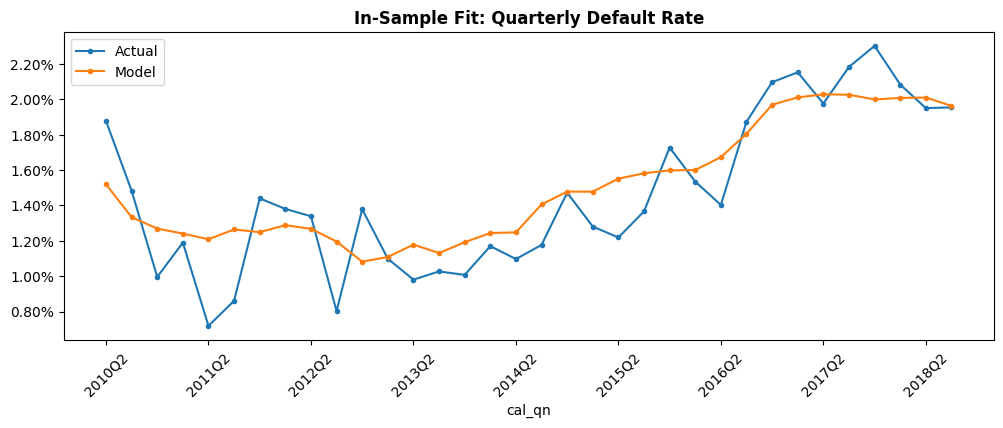

In [4]:
print("--- Estimating the Hazard Models ---")

def fit_logit_irls(X, y, max_iter=100, tol=1e-9, ridge=1e-8):
    """Logistic regression by Newton-Raphson (IRLS) with robust standard errors (see Part 1)."""
    X = np.asarray(X, float); y = np.asarray(y, float)
    k = X.shape[1]
    beta = np.zeros(k); beta[0] = logit(np.clip(y.mean(), 1e-6, 1 - 1e-6))
    def loglik(b):
        mu = np.clip(expit(X @ b), 1e-12, 1 - 1e-12)
        return np.sum(y * np.log(mu) + (1 - y) * np.log(1 - mu))
    ll_old = loglik(beta)
    for it in range(max_iter):
        mu = expit(X @ beta)
        step = np.linalg.solve((X * (mu * (1 - mu))[:, None]).T @ X + ridge * np.eye(k), X.T @ (y - mu))
        t = 1.0
        while loglik(beta + t * step) < ll_old - 1e-10 and t > 1e-4:
            t /= 2
        beta = beta + t * step
        ll_new = loglik(beta)
        if np.max(np.abs(t * step)) < tol or abs(ll_new - ll_old) < tol:
            break
        ll_old = ll_new
    mu = expit(X @ beta)
    A_inv = np.linalg.inv((X * (mu * (1 - mu))[:, None]).T @ X + ridge * np.eye(k))
    score = X * (y - mu)[:, None]
    return {'beta': beta, 'se_robust': np.sqrt(np.diag(A_inv @ (score.T @ score) @ A_inv)), 'n_iter': it + 1}

def predict_logit(fit, X):
    return expit(np.asarray(X, float) @ fit['beta'])

class Design:
    """Imputes, standardizes and one-hot encodes using training-set statistics (see Part 1)."""
    def __init__(self, frame, num, cat, min_count=200):
        self.num, self.cat = num, cat
        self.median = frame[num].median()
        filled = frame[num].fillna(self.median)
        self.mean, self.std = filled.mean(), filled.std().replace(0, 1)
        self.levels = {}
        for c in cat:
            counts = frame[c].fillna('missing').value_counts()
            self.levels[c] = counts[counts >= min_count].index.tolist()[1:]
    def transform(self, frame):
        Z = (frame[self.num].fillna(self.median) - self.mean) / self.std
        parts = [pd.Series(1.0, index=frame.index, name='const'), Z]
        for c, lv in self.levels.items():
            col = frame[c].fillna('missing')
            parts.append(pd.DataFrame({f'{c}={l}': (col == l).astype(float) for l in lv}, index=frame.index))
        return pd.concat(parts, axis=1)

def fit_hazard(frame, num, cat, target):
    design = Design(frame, num, cat, min_count=0)
    X = design.transform(frame)
    return design, fit_logit_irls(X, frame[target].values), X.columns

MACRO_VARS = ['ur_lag', 'dur4_lag', 'gdp_lag']
DEF_NUM = ['fico', 'dti', 'log_annual_inc', 'revol_util', 'term_60'] + MACRO_VARS
DEF_CAT = ['grade', 'home_ownership', 'age_b']
PRE_NUM = ['fico', 'dti', 'log_annual_inc', 'int_rate', 'term_60']
PRE_CAT = ['grade', 'age_b']

# 1. Fit the default and prepayment hazards
def_design, def_fit, def_cols = fit_hazard(panel, DEF_NUM, DEF_CAT, 'd_default')
pre_design, pre_fit, pre_cols = fit_hazard(panel, PRE_NUM, PRE_CAT, 'd_prepay')
print(f"Default hazard converged in {def_fit['n_iter']} iterations; prepayment hazard in {pre_fit['n_iter']}")

# 2. Coefficient table
z = def_fit['beta'] / def_fit['se_robust']
coef_df = pd.DataFrame({'Coefficient': def_fit['beta'], 'Robust SE': def_fit['se_robust'],
                        'p-value': 2 * stats.norm.sf(np.abs(z)), 'Odds Ratio': np.exp(def_fit['beta'])},
                       index=def_cols)
coef_df['Odds Ratio per Unit'] = np.exp(coef_df['Coefficient'] / def_design.std.reindex(def_cols))
print("\n--- Default Hazard Coefficients ---")
display(coef_df.round(4))

# 3. Sign check
print("--- Sign Check (Economic Intuition) ---")
expected_signs = {'ur_lag': +1, 'dur4_lag': +1, 'gdp_lag': -1, 'fico': -1, 'dti': +1, 'term_60': +1}
for var, sign in expected_signs.items():
    ok = np.sign(coef_df.loc[var, 'Coefficient']) == sign
    print(f"{'OK  ' if ok else 'FLAG'}  {var:9s} coef = {coef_df.loc[var, 'Coefficient']:+.4f} "
          f"(p = {coef_df.loc[var, 'p-value']:.3f}), expected {'+' if sign > 0 else '-'}")

# 4. In-sample fit: quarterly default rate, actual vs. model
panel['hazard_hat'] = predict_logit(def_fit, def_design.transform(panel))
fit_q = panel.groupby('cal_qn').agg(Actual=('d_default', 'mean'), Model=('hazard_hat', 'mean'), n=('d_default', 'size'))
fit_q = fit_q[fit_q['n'] >= 500]
ax = fit_q[['Actual', 'Model']].plot(figsize=(12, 4), marker='.')
ax.set_xticks(fit_q.index[::4]); ax.set_xticklabels([qlabel(q) for q in fit_q.index[::4]], rotation=45)
ax.set_title('In-Sample Fit: Quarterly Default Rate', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2%}'))
plt.show()

### Results

1. **Borrower risk and loan age are well captured.**
   * **Grade:** the default odds rise steadily from grade A (0.48× grade B) to grade G (5.84×).
   * **Borrower data:** higher FICO (−0.4% odds per point) and lower DTI (+0.4% per point) work as expected.
   * **Loan age:** the odds in the first quarter are 0.05× those at the peak ages (5–6 quarters), which matches Step 2.
2. **The economic variables fail the sign check.** Only 3 of 6 checks pass (`dur4_lag`, `fico`, `dti`).
   * **`ur_lag` (wrong sign, significant):** +1 point of unemployment *lowers* the odds of default by 4.7% (odds ratio 0.953). This makes no economic sense.
   * **`dur4_lag` (correct):** a *rising* unemployment rate raises the odds by **8.9% per point** of change over 4 quarters. This is the only economic variable that behaves as expected.
   * **`gdp_lag` (wrong sign, not significant):** no measurable effect.
   * **`term_60` (wrong sign):** with grade held constant, 60-month loans show *lower* odds. Lending Club already gives 60-month loans worse grades, so the grade variables absorb their extra risk.
3. **Diagnosis: a missing vintage effect.** From 2010 to 2018, unemployment fell every year while Lending Club's new loans became riskier. The model has no variable for the quality of each year's lending, so it links the rising defaults to the falling unemployment. This is a classic case of **omitted variable bias**. The fix is to add issue-year (vintage) effects, or to measure the economic effect only from differences between states.
4. **The in-sample fit looks good but is misleading.** The model follows the rise in the quarterly default rate from about 1.2% (2012–2014) to about 2.0% (2017–2018), but for the wrong reason.

# Step 4: Out-of-Time Backtest

**Why this step?** A good fit on the data used to build the model is easy. The real test is whether a model built on the past predicts the **future** when we give it the economy that actually happened. This is how a validator would test a stress model.

**How we do it.**
1. We fit the model again, using only quarters up to `BT_END` (8 quarters before the end of the panel).
2. We predict the default rate of every loan-quarter in the next 8 quarters, using the real economic data.
3. We compare predicted and actual default rates each quarter.

We run the same test for a **model without economic variables**. If the economic model does not predict better, the link with the economy adds no value.

--- Out-of-Time Backtest ---
Estimated up to 2016Q3, predicted 2016Q4 to 2018Q3


,Mean Abs. Error (pp),Predicted / Actual Defaults
With Macro,0.3352,0.8401
No Macro (Benchmark),0.3319,0.8419


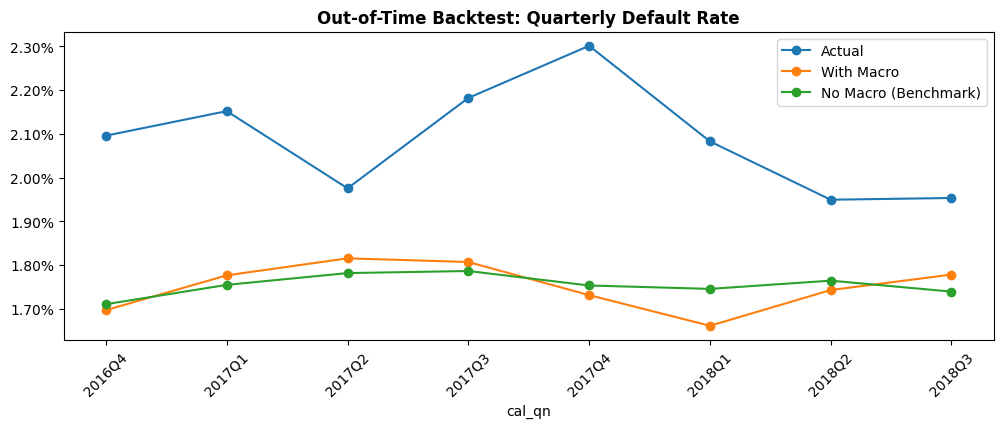

In [5]:
print("--- Out-of-Time Backtest ---")
BT_END = END_QN - BACKTEST_Q
bt_train = panel[panel['cal_qn'] <= BT_END]
bt_test = panel[panel['cal_qn'] > BT_END].copy()

backtest_models = {'With Macro': DEF_NUM, 'No Macro (Benchmark)': [v for v in DEF_NUM if v not in MACRO_VARS]}
for name, num_vars in backtest_models.items():
    d_bt, f_bt, _ = fit_hazard(bt_train, num_vars, DEF_CAT, 'd_default')
    bt_test[name] = predict_logit(f_bt, d_bt.transform(bt_test))

bt_q = bt_test.groupby('cal_qn')[['d_default'] + list(backtest_models)].mean().rename(columns={'d_default': 'Actual'})
bt_errors = pd.DataFrame({name: {'Mean Abs. Error (pp)': 100 * np.mean(np.abs(bt_q[name] - bt_q['Actual'])),
                                 'Predicted / Actual Defaults': bt_test[name].sum() / bt_test['d_default'].sum()}
                          for name in backtest_models}).T
print(f"Estimated up to {qlabel(BT_END)}, predicted {qlabel(BT_END + 1)} to {qlabel(END_QN)}")
display(bt_errors.round(4))

ax = bt_q.plot(figsize=(12, 4), marker='o')
ax.set_xticks(bt_q.index); ax.set_xticklabels([qlabel(q) for q in bt_q.index], rotation=45)
ax.set_title('Out-of-Time Backtest: Quarterly Default Rate', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2%}'))
plt.show()

### Results

1. **Both models miss the level.** From 2016 Q4 to 2018 Q3, the actual quarterly default rate was **1.95–2.30%**, but both models predicted only **1.66–1.82%**. Total predicted defaults are **84%** of actual defaults: a **16% under-prediction**. The models learned from older, safer loans and could not foresee the riskier 2016–2017 loans. It is the same vintage problem, now seen out of time.
2. **The economic variables add nothing.** The average error is **0.335 points** with them and **0.332 points** without them. The economic model is even slightly worse.
3. **Validation conclusion.** A model validator would rate this PD model **not fit for scenario analysis** in its current form: wrong sign on the unemployment level, no gain from the economic variables, and a 16% under-prediction. We still run the full stress test in the next steps, because the rest of the machinery (scenarios, state translation, EAD schedule, LGD link) is correct and reusable. But the size of the stress effect must be read with this conclusion in mind.

# Step 5: Scenarios and State Translation

**Why this step?** A stress test needs clear, consistent economic stories. The scenarios are written for the whole US, but our model uses state unemployment, so we must translate them to each state.

**How we do it.** We define three 9-quarter paths that start from the real values at the snapshot date:

| Scenario | Unemployment | Real GDP growth (per year) | Story |
|---|---|---|---|
| Baseline | stays at the starting level | +2% | normal growth |
| Adverse | +3 points, peak after about 5 quarters | down to −1.5% | mild recession |
| Severely adverse | up to **10%**, peak after about 5 quarters | down to −6% | deep recession, similar to 2008–09 |

The severely adverse path matches the headline of the Federal Reserve's 2025 severely adverse scenario: unemployment rises from 4.1% to 10% and real GDP falls 7.8% from peak to low point.

If the macro data goes beyond the snapshot date, we add a fourth scenario, the **real path** that followed. For a 2019 snapshot, this includes the **COVID shock of 2020**. Unemployment then rose more than in our severe scenario, but consumer credit losses stayed low, because payment breaks and government support cut the usual link between job loss and default. This scenario shows the risk of a model built on history when the world changes.

To translate a US path to each state, we estimate how strongly each state's unemployment follows the national rate (the state "beta"), and scale the national shock by it (see the model review).

--- Scenario Design ---
Least cyclical states: {'ND': 0.24, 'AK': 0.38, 'NE': 0.38}
Most cyclical states:  {'OR': 1.18, 'NC': 1.26, 'MI': 1.39}
Realized macro path available -> added as a 4th scenario


,Baseline,Adverse,Severely Adverse,Realized Path
2019Q2,3.87,4.62,5.40,3.63
2019Q3,3.87,5.37,6.93,3.60
2019Q4,3.87,6.12,8.47,3.60
2020Q1,3.87,6.57,9.39,3.83
2020Q2,3.87,6.87,10.00,13.00
2020Q3,3.87,6.87,10.00,8.80
2020Q4,3.87,6.72,9.69,6.77
2021Q1,3.87,6.57,9.39,6.23
2021Q2,3.87,6.42,9.08,5.93


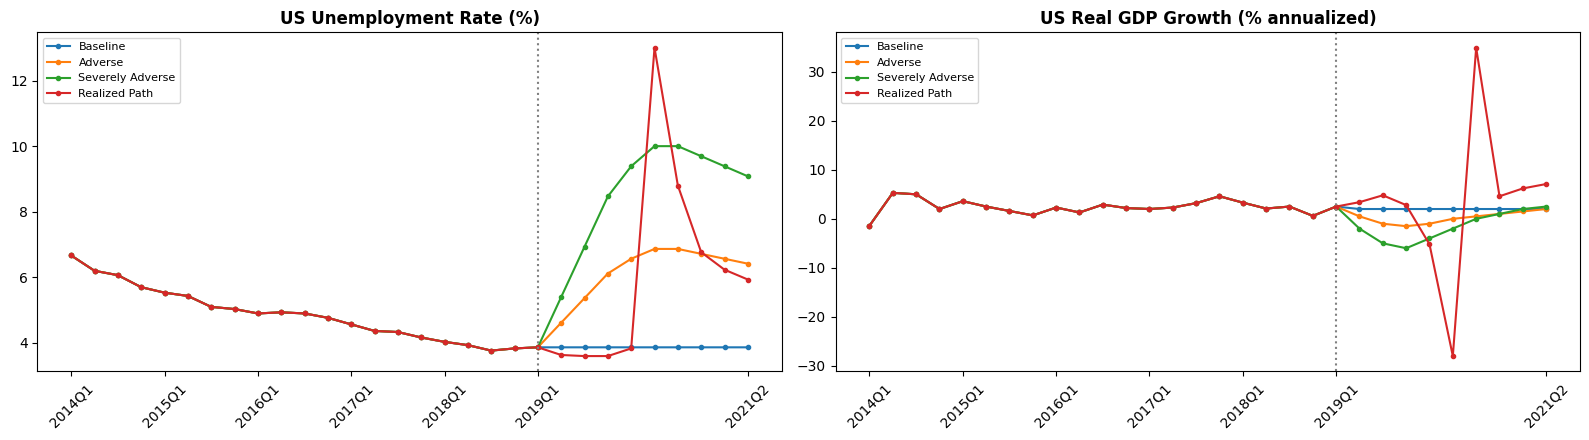

In [6]:
print("--- Scenario Design ---")

# 1. National scenario paths
hist_us = macro_us[macro_us['qn'] <= AS_OF_QN].set_index('qn')
u0 = hist_us.loc[AS_OF_QN, 'ur_us']
shape = np.array([0.25, 0.50, 0.75, 0.90, 1.00, 1.00, 0.95, 0.90, 0.85])   # timing of the shock
GDP_BASE = np.full(H, 2.0)
GDP_ADV = np.array([0.5, -1.0, -1.5, -1.0, 0.0, 0.5, 1.0, 1.5, 2.0])
GDP_SEV = np.array([-2.0, -5.0, -6.0, -4.0, -2.0, 0.0, 1.0, 2.0, 2.5])

def us_scenario(peak_ur):
    """Unemployment path to a given peak; GDP scaled between baseline and severe accordingly."""
    k = np.clip((peak_ur - u0) / max(10.0 - u0, 1e-6), 0, None)
    return {'ur_us': u0 + (peak_ur - u0) * shape, 'gdp_growth': GDP_BASE + k * (GDP_SEV - GDP_BASE)}

SCENARIOS = {
    'Baseline': {'ur_us': np.full(H, u0), 'gdp_growth': GDP_BASE},
    'Adverse': {'ur_us': u0 + 3.0 * shape, 'gdp_growth': GDP_ADV},
    'Severely Adverse': {'ur_us': u0 + (10.0 - u0) * shape, 'gdp_growth': GDP_SEV},
}
proj_q = np.arange(AS_OF_QN + 1, AS_OF_QN + H + 1)

# 2. State betas: sensitivity of each state's unemployment to the national cycle
hist_state = macro_state[macro_state['qn'] <= AS_OF_QN]
state_wide = hist_state.pivot(index='qn', columns='state', values='ur').sort_index()
d_us = hist_us['ur_us'].reindex(state_wide.index).diff()
state_beta = {}
for s in state_wide.columns:
    d_s = state_wide[s].diff()
    m = d_s.notna() & d_us.notna()
    state_beta[s] = float((d_s[m] * d_us[m]).sum() / (d_us[m] ** 2).sum())   # OLS through the origin
state_beta = pd.Series(state_beta).sort_values()
print(f"Least cyclical states: {state_beta.head(3).round(2).to_dict()}")
print(f"Most cyclical states:  {state_beta.tail(3).round(2).to_dict()}")

# 3. Build a macro cube (history + projection) for each scenario
def build_cube(us_path):
    ur_T = state_wide.loc[AS_OF_QN]
    rows = []
    for h, q in enumerate(proj_q):
        ur_s = (ur_T + state_beta.reindex(ur_T.index).fillna(1.0) * (us_path['ur_us'][h] - u0)).clip(lower=2.0)
        rows.append(pd.DataFrame({'state': ur_s.index, 'qn': q, 'ur': ur_s.values,
                                  'gdp_growth': us_path['gdp_growth'][h], 'ur_us': us_path['ur_us'][h]}))
    hist = hist_state[['state', 'qn', 'ur']].merge(hist_us[['gdp_growth', 'ur_us']], left_on='qn', right_index=True)
    full = pd.concat([hist, *rows], ignore_index=True).sort_values(['state', 'qn'])
    full['ur_chg4'] = full.groupby('state')['ur'].diff(4)
    return MacroCube(full)

cubes = {name: build_cube(path) for name, path in SCENARIOS.items()}

# 4. Realized path (only if the macro data covers the full horizon)
if set(proj_q) <= (set(macro_us['qn']) & set(macro_state['qn'])):
    cubes['Realized Path'] = MacroCube(macro_all)
    realized = macro_us.set_index('qn').loc[proj_q]
    SCENARIOS['Realized Path'] = {'ur_us': realized['ur_us'].values, 'gdp_growth': realized['gdp_growth'].values}
    print("Realized macro path available -> added as a 4th scenario")

display(pd.DataFrame({k: v['ur_us'] for k, v in SCENARIOS.items()}, index=[qlabel(q) for q in proj_q]).round(2))

# 5. Plot the scenarios
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
hq = hist_us.index[hist_us.index >= AS_OF_QN - 20]
for name, path in SCENARIOS.items():
    for ax, var in zip(axes, ['ur_us', 'gdp_growth']):
        ax.plot(list(hq) + list(proj_q), list(hist_us.loc[hq, var]) + list(path[var]), marker='.', label=name)
for ax, title in zip(axes, ['US Unemployment Rate (%)', 'US Real GDP Growth (% annualized)']):
    ax.axvline(AS_OF_QN, color='grey', ls=':')
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=8)
    ticks = list(hq[::4]) + [proj_q[-1]]
    ax.set_xticks(ticks); ax.set_xticklabels([qlabel(q) for q in ticks], rotation=45)
plt.tight_layout(); plt.show()

### Results

1. **The scenarios.**
   * **Start:** US unemployment of 3.87% in 2019 Q1.
   * **Adverse:** peaks at **6.87%**.
   * **Severely adverse:** peaks at **10.0%** in 2020 Q2–Q3, with GDP falling to −6%.
   * **Real path:** stayed near 3.6% until 2020 Q1, jumped to **13.0%** in 2020 Q2 (quarterly average), and was back at 5.9% by 2021 Q2. This shock was deeper but much shorter than our severe scenario.
2. **States react very differently.** State betas range from **0.24 (North Dakota)** to **1.39 (Michigan)**. Alaska and Nebraska are also among the least sensitive states, Oregon and North Carolina among the most sensitive. A +6-point national shock becomes about +1.5 points in North Dakota but +8.4 points in Michigan. Loans in sensitive states therefore carry more stress risk.

# Step 6: The Loss Projection Engine

**Why this step?** This is where PD, LGD and EAD come together to produce a dollar loss for each quarter.

**How we do it.**
* **Starting portfolio:** all loans that were *current* with a positive balance at the snapshot date. Delinquent loans are already on the way to default; a bank would provision for them separately, so we report their balance but leave them out.
* **Static balance sheet:** no new loans are added. Existing loans shrink through scheduled payments, prepayments and defaults. This is the standard assumption in regulatory stress tests.

For each quarter $h = 1, \dots, 9$, the engine:
1. adds one quarter to the age of every loan;
2. looks up last quarter's economy in the loan's state under the scenario;
3. computes the default and prepayment probabilities;
4. computes the probability of surviving to the quarter and then defaulting in it, $S_{t-1} h^D_t$;
5. multiplies this by EAD (the scheduled balance) and by LGD (the Part 1 model at the state unemployment rate of that quarter);
6. updates the survival probability.

The engine takes one economy for PD and one for LGD. This lets us measure the effect of each channel separately in Step 7.

In [7]:
print("--- Preparing the Starting Portfolio ---")

# 1. Current loans at the snapshot date
port = loan_features(lc[lc['outcome'].eq('current') & (lc['out_prncp'] > 0)])
port = port[port['addr_state'].isin(STATES)].reset_index(drop=True)
START_BAL = port['out_prncp'].sum()
delinquent_bal = lc.loc[lc['outcome'].eq('delinquent'), 'out_prncp'].sum()
print(f"Projected portfolio: {len(port):,} current loans, balance ${START_BAL / 1e6:,.1f}M")
print(f"Excluded delinquent balance: ${delinquent_bal / 1e6:,.1f}M")

# 2. Scheduled amortization -> EAD at the start of each projection quarter
as_of_mn = AS_OF.year * 12 + AS_OF.month
remaining_m = (port['term_m'] - (as_of_mn - (port['issue_m'].dt.year * 12 + port['issue_m'].dt.month))).clip(lower=1).values
r_month = port['int_rate'].values / 1200
B = np.zeros((len(port), 3 * H + 1)); B[:, 0] = port['out_prncp'].values
for m in range(1, 3 * H + 1):
    B[:, m] = np.where(m < remaining_m, np.maximum(B[:, m - 1] * (1 + r_month) - port['installment'].values, 0), 0)
EAD = B[:, 0:3 * H:3]   # EAD[:, h-1] = balance at the start of quarter h

# 3. LGD from the Part 1 satellite model (floored at the long-run average)
alpha = pd.Series(lgd_sat['alpha_by_grade']); lra = pd.Series(lgd_sat['lra_by_grade'])
gamma_eff = lgd_sat['gamma_ur'] if (lgd_sat['gamma_ur'] > 0 and lgd_sat['gamma_p_value'] < 0.10) else 0.0
alpha_i = port['grade'].map(alpha).fillna(alpha.mean()).values
lra_i = port['grade'].map(lra).fillna(lgd_sat['lra_default_weighted']).values
print(f"LGD sensitivity to unemployment used: gamma = {gamma_eff:.4f}")

def lgd_fn(ur):
    return np.maximum(expit(alpha_i + gamma_eff * ur), lra_i)

# 4. The projection engine
BASE_COLS = ['grade', 'home_ownership', 'fico', 'dti', 'log_annual_inc', 'revol_util', 'int_rate', 'term_60', 'addr_state']

def project(cube_pd, cube_lgd):
    """9-quarter projection. cube_pd drives the default hazard; cube_lgd drives LGD."""
    survival = np.ones(len(port)); loan_loss = np.zeros(len(port)); rows = []
    for h, q in enumerate(proj_q, start=1):
        fr = port[BASE_COLS].copy()
        fr['age'] = (AS_OF_QN - port['issue_qn'].values) + h
        fr['age_b'] = age_bucket(fr['age'])
        fr['cal_qn'] = q
        fr = add_macro(fr, cube_pd)
        h_def = predict_logit(def_fit, def_design.transform(fr))
        h_pre = predict_logit(pre_fit, pre_design.transform(fr))
        ead = EAD[:, h - 1]; alive = ead > 0
        lgd = lgd_fn(cube_lgd.get('ur', port['addr_state'].values, np.full(len(port), q)))
        pd_marginal = survival * h_def * alive
        loss = pd_marginal * ead * lgd
        loan_loss += loss
        rows.append({'Quarter': qlabel(q), 'Expected Defaults': pd_marginal.sum(),
                     'Defaulted Balance': (pd_marginal * ead).sum(), 'Loss': loss.sum(),
                     'Avg Hazard': np.average(h_def, weights=survival * ead + 1e-12)})
        survival = np.clip(survival * (1 - h_def - h_pre), 0, 1) * alive
    out = pd.DataFrame(rows).set_index('Quarter')
    out['Cumulative Loss'] = out['Loss'].cumsum()
    return out, loan_loss

print("Projection engine ready.")

--- Preparing the Starting Portfolio ---
Projected portfolio: 873,780 current loans, balance $9,125.8M
Excluded delinquent balance: $384.2M
LGD sensitivity to unemployment used: gamma = 0.0422
Projection engine ready.


# Step 7: Stress Test Results

**Why this step?** We now run the engine under every scenario and look at the results from three angles:
1. **Loss by scenario:** the 9-quarter loss rate, the cumulative PD, the average LGD, and the loss path by quarter.
2. **PD vs. LGD:** we run the severe scenario twice more, once with only PD stressed (LGD at baseline) and once with only LGD stressed. The rest is the **interaction**: more defaults *and* a higher loss on each default.
3. **Loss by grade:** where the stress loss is concentrated.

--- Running the Stress Test ---

--- Scenario Summary ---


,9Q Loss ($M),9Q Loss Rate,Cumulative PD,Implied LGD,Peak Quarterly Hazard,x Baseline
Baseline,868.1621,0.0951,0.1044,0.9116,0.0250,1.0000
Adverse,876.7774,0.0961,0.1051,0.9142,0.0264,1.0099
Severely Adverse,888.2349,0.0973,0.1058,0.9202,0.0281,1.0231
Realized Path,922.7059,0.1011,0.1104,0.9158,0.0428,1.0628


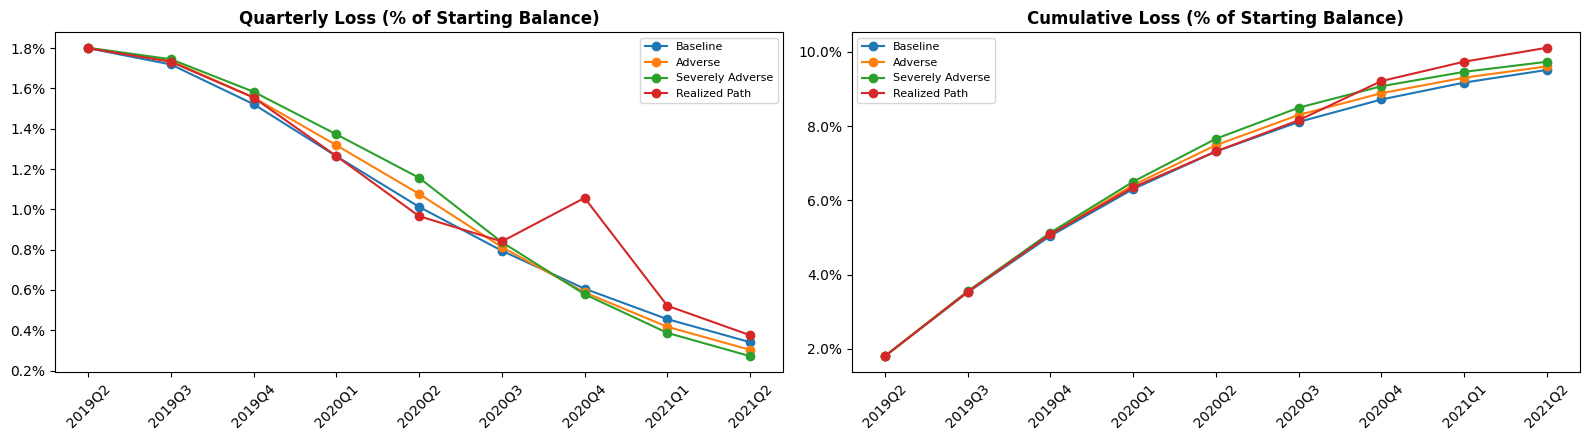


--- Decomposition of the Severely Adverse Loss ($M) ---


,$M
Baseline Loss,868.16
+ PD Channel,11.82
+ LGD Channel,8.06
+ Interaction,0.20
Severely Adverse Loss,888.23


Share of the stress add-on explained by PD: 59%

--- 9-Quarter Loss Rate by Grade ---


,Baseline,Adverse,Severely Adverse,Realized Path,Balance Share
grade,,,,,
A,0.0289,0.0293,0.0298,0.0307,0.2170
B,0.0645,0.0652,0.0662,0.0688,0.2850
C,0.1120,0.1131,0.1145,0.1193,0.2973
D,0.1665,0.1680,0.1700,0.1770,0.1400
E,0.2080,0.2099,0.2124,0.2193,0.0454
F,0.2790,0.2812,0.2842,0.2923,0.0116
G,0.3236,0.3261,0.3294,0.3370,0.0038


In [8]:
print("--- Running the Stress Test ---")

# 1. Losses by scenario
projections, loan_losses = {}, {}
for name in SCENARIOS:
    projections[name], loan_losses[name] = project(cubes[name], cubes[name])

summary = pd.DataFrame({
    name: {'9Q Loss ($M)': p['Loss'].sum() / 1e6,
           '9Q Loss Rate': p['Loss'].sum() / START_BAL,
           'Cumulative PD': p['Defaulted Balance'].sum() / START_BAL,
           'Implied LGD': p['Loss'].sum() / p['Defaulted Balance'].sum(),
           'Peak Quarterly Hazard': p['Avg Hazard'].max()}
    for name, p in projections.items()}).T
summary['x Baseline'] = summary['9Q Loss Rate'] / summary.loc['Baseline', '9Q Loss Rate']
print("\n--- Scenario Summary ---")
display(summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for name, p in projections.items():
    axes[0].plot(p.index, p['Loss'] / START_BAL, marker='o', label=name)
    axes[1].plot(p.index, p['Cumulative Loss'] / START_BAL, marker='o', label=name)
axes[0].set_title('Quarterly Loss (% of Starting Balance)', fontweight='bold')
axes[1].set_title('Cumulative Loss (% of Starting Balance)', fontweight='bold')
for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# 2. PD vs. LGD decomposition of the severely adverse add-on
base_loss = projections['Baseline']['Loss'].sum()
severe_loss = projections['Severely Adverse']['Loss'].sum()
pd_only = project(cubes['Severely Adverse'], cubes['Baseline'])[0]['Loss'].sum()
lgd_only = project(cubes['Baseline'], cubes['Severely Adverse'])[0]['Loss'].sum()
decomposition = pd.Series({'Baseline Loss': base_loss,
                           '+ PD Channel': pd_only - base_loss,
                           '+ LGD Channel': lgd_only - base_loss,
                           '+ Interaction': severe_loss - pd_only - lgd_only + base_loss,
                           'Severely Adverse Loss': severe_loss}) / 1e6
pd_share = (pd_only - base_loss) / (severe_loss - base_loss)
print("\n--- Decomposition of the Severely Adverse Loss ($M) ---")
display(decomposition.to_frame('$M').round(2))
print(f"Share of the stress add-on explained by PD: {pd_share:.0%}")

# 3. Loss rate by grade
by_grade = pd.DataFrame({name: pd.Series(ll).groupby(port['grade']).sum() / port.groupby('grade')['out_prncp'].sum()
                         for name, ll in loan_losses.items()})
by_grade['Balance Share'] = port.groupby('grade')['out_prncp'].sum() / START_BAL
print("\n--- 9-Quarter Loss Rate by Grade ---")
display(by_grade.round(4))

### Results

1. **The scenarios barely differ.**

| Scenario | 9-quarter loss | Loss rate | × baseline |
|---|---|---|---|
| Baseline | \$868M | 9.51% | 1.00 |
| Adverse | \$877M | 9.61% | 1.01 |
| Severely adverse | \$888M | 9.73% | 1.02 |
| Real path (2019–21) | \$923M | 10.11% | 1.06 |

   In the baseline, the cumulative PD is 10.4% and the average LGD 91.2%. For comparison, the Federal Reserve's 2025 stress test projected a 9-quarter loss rate of 16.9% for bank credit cards under its severely adverse scenario. A loss increase of only 2% when unemployment more than doubles is **not credible**. It is a direct result of the wrong-signed unemployment effect found in Step 3.
2. **The quarterly path shows the problem.** In the severe scenario, losses first rise above baseline while unemployment is *rising*, because the change variable (`dur4_lag`) works correctly. From 2020 Q4, when unemployment stays high, losses fall *below* baseline, because the wrong-signed level variable (`ur_lag`) takes over. In other words, the model says that a *long* period of 10% unemployment reduces defaults.
3. **PD vs. LGD.** Of the \$20.1M extra loss in the severe scenario, the **PD channel** gives 59% (\$11.8M), the **LGD channel** 40% (\$8.1M, from the Part 1 model), and the interaction 1%. The LGD channel works as designed; the PD channel is too weak.
4. **Loss by grade.** The baseline loss rate rises from **2.9% (grade A)** to **32.4% (grade G)**. In dollars, the middle grades matter most. Grade C (29.7% of the balance, 11.2% loss rate) causes about 35% of the total loss and grade D (14.0%, 16.7%) about 25%. Together, grades C and D carry **60% of the loss with 44% of the balance**.
5. **Real path.** The model projects a 10.1% loss under the real 2019–21 economy. We cannot use this period to test the model, because payment breaks and government support changed borrower behavior across all consumer credit.

# Step 8: Sensitivity and Reverse Stress Test

**Why this step?** Three scenarios give only three points. A **sensitivity curve** shows the full picture: we run the projection for a range of peak unemployment rates, with GDP moving in line.

A **reverse stress test** reads the curve the other way. Instead of *"what is the loss in scenario X?"*, it asks *"which scenario causes an unacceptable loss?"*. Here, "unacceptable" means **twice the baseline loss**. In a bank, it would be the loss that uses up the capital buffer.

--- Sensitivity Curve (this re-runs the projection ~11 times) ---


,9Q Loss Rate
Peak US Unemployment (%),
4.0,0.0952
5.0,0.0954
6.0,0.0956
7.0,0.0960
8.0,0.0964
9.0,0.0969
10.0,0.0973
11.0,0.0978
12.0,0.0983



Reverse Stress Test: Doubling the baseline loss (19.03%) requires unemployment above 14%.


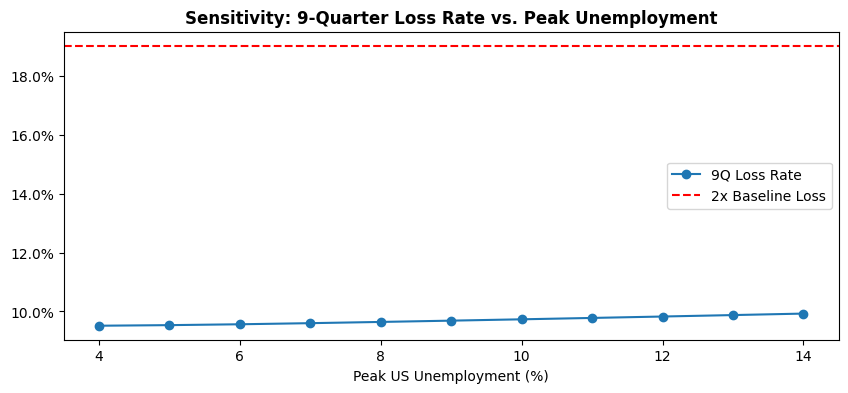

In [9]:
print("--- Sensitivity Curve (this re-runs the projection ~11 times) ---")

peaks = np.arange(np.ceil(u0), 15.0, 1.0)
sensitivity = pd.Series({pk: project(build_cube(us_scenario(pk)), build_cube(us_scenario(pk)))[0]['Loss'].sum() / START_BAL
                         for pk in peaks}, name='9Q Loss Rate')
sensitivity.index.name = 'Peak US Unemployment (%)'
display(sensitivity.to_frame().round(4))

# Reverse stress test: which unemployment peak doubles the baseline loss?
target = 2 * summary.loc['Baseline', '9Q Loss Rate']
if sensitivity.max() >= target and sensitivity.is_monotonic_increasing:
    ur_star = np.interp(target, sensitivity.values, sensitivity.index.values)
    reverse_msg = f"A peak unemployment rate of about {ur_star:.1f}% doubles the baseline loss ({target:.2%})."
else:
    reverse_msg = f"Doubling the baseline loss ({target:.2%}) requires unemployment above {peaks[-1]:.0f}%."
print(f"\nReverse Stress Test: {reverse_msg}")

ax = sensitivity.plot(marker='o', figsize=(10, 4))
ax.axhline(target, color='red', ls='--', label='2x Baseline Loss')
ax.set_title('Sensitivity: 9-Quarter Loss Rate vs. Peak Unemployment', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}')); ax.legend()
plt.show()

### Results

1. **Sensitivity is very low.** The 9-quarter loss rate goes from **9.52%** at a 4% unemployment peak to only **9.93%** at 14%, about **+0.04 points per point** of unemployment. The curve is almost a straight line. Real consumer portfolios usually show losses that speed up as a recession deepens, and there is no sign of that here.
2. **Reverse stress test.** Doubling the baseline loss (to 19.0%) would need unemployment **above 14%**, outside our range. The US reached about 10% in 2009 and about 13% (quarterly average) in 2020. Taken at face value, no recession in history could break this portfolio. That is not believable, and it confirms that the economic sensitivity is far too low. **A reverse stress test that finds no plausible breaking point is itself a warning sign.**

# Summary of Part 4

We built a stress test for **873,780 current Lending Club loans (\$9.13 billion)**, and projected 9-quarter losses under baseline, adverse and severely adverse scenarios and under the real 2019–21 economy. The loss engine works, but the validation shows that the PD model **understates the effect of the economy**. The main result of this part is a model risk finding and its diagnosis.

**Model design**
* **PD:** hazard model on **849,045 loan-quarters** (15,218 defaults), with loan age, borrower risk, lagged state unemployment and GDP, plus a prepayment model.
* **LGD:** the Part 1 model (+0.34 points per point of unemployment), never below the 91% long-run average.
* **EAD:** the scheduled balance of each loan.
* **Scenarios:** US paths translated to states with state betas (0.24–1.39).

**Results**

| Scenario | Peak unemployment | 9-quarter loss (\$M) | Loss rate | × baseline |
| --- | --- | --- | --- | --- |
| Baseline | 3.9% | 868 | 9.51% | 1.00 |
| Adverse | 6.9% | 877 | 9.61% | 1.01 |
| Severely adverse | 10.0% | 888 | 9.73% | 1.02 |
| Real path (2019–21) | 13.0% | 923 | 10.11% | 1.06 |

**Validation**
* **Sign check:** 3 of 6 signs correct. The unemployment level (wrong and significant), GDP (not significant) and the 60-month term (absorbed by grade) are flagged.
* **Backtest (2016 Q4–2018 Q3):** average error 0.335 points with economic variables vs. 0.332 without; both under-predict defaults by 16%.
* **Root cause:** a missing vintage effect. Lending became riskier (default share 14% → 23%) while unemployment fell (10% → 4%).
* **Conclusion:** not fit for scenario analysis without changes. The losses above are a **lower bound**.

**How to fix the model**
1. Add **issue-year (vintage) effects**, so the economic effect is measured over time *within* each vintage.
2. Add **state effects**, or keep only the change in unemployment (`dur4_lag`), which already has the correct sign (+8.9% odds per point).
3. Until the model passes, apply a **management overlay**: scale the stressed PDs with an external benchmark sensitivity.
4. Repeat the sign check, the backtest and the reverse stress test before approval.

**Limitations**
1. **Weak identification.** 2010–2018 has no recession, and unemployment moved in one direction only.
2. **Extrapolation.** The scenarios take unemployment beyond most of the data.
3. **Static balance sheet.** No new loans, no management actions, no government support.
4. **Parameter uncertainty.** We use point estimates; bootstrapping would give a range of losses.
5. **Prepayment does not react to the economy.** In a recession, prepayments usually fall, which leaves more balance at risk.

**Next:** Part 5 looks at the same loans from an investor's side: buying them every month, checking them against expectations, and financing them with a securitization.